In [27]:
# EDA
import pandas as pd
import pingouin as pg
import plotly.express as px
import plotly.figure_factory as ff
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Otimização de Hiperparametros
import optuna

In [2]:
df_transacoes = pd.read_csv('./datasets/transacoes_fraude.csv')

In [3]:
df_transacoes.head(10)

,Cliente,Tipo de Transacao,Valor da Transacao,Valor Anterior a Transacao,Valor Apos a Transacao,Horario da Transacao,Classe
0,cliente1D4F0B,Saque,390.39,5446.75,5056.36,2023-03-14T07:29:28.256579,0
1,clienteCF3D89,Saque,3272.03,12167.89,8895.86,2023-02-12T17:54:09.119410,0
2,cliente0F0D32,PIX,4905.72,8217.63,3311.91,2023-10-03T17:31:42.087599,0
3,clienteFCC0EA,PIX,3073.23,7833.16,4759.93,2024-05-23T17:57:02.055680,0
4,cliente9BA227,PIX,4233.03,6920.82,2687.79,2022-10-07T17:30:36.879557,0
5,cliente62C357,Débito,4848.49,7354.41,2505.92,2025-07-08T19:16:37.207970,0
6,cliente320C76,Crédito,1600.44,7296.87,5696.43,2024-09-07T02:23:16.975044,0
7,cliente32CB58,Crédito,1296.71,10562.92,9266.21,2023-08-28T23:09:19.817457,0
8,cliente67AFD9,Débito,1187.35,10935.18,9747.83,2024-05-21T09:01:08.163132,0
9,cliente84F77D,PIX,3271.51,3405.61,134.10,2022-09-26T10:33:12.415982,0


In [4]:
df_transacoes.info()

<class 'pandas.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Cliente                     13000 non-null  str    
 1   Tipo de Transacao           13000 non-null  str    
 2   Valor da Transacao          13000 non-null  float64
 3   Valor Anterior a Transacao  13000 non-null  float64
 4   Valor Apos a Transacao      13000 non-null  float64
 5   Horario da Transacao        13000 non-null  str    
 6   Classe                      13000 non-null  int64  
dtypes: float64(3), int64(1), str(3)
memory usage: 711.1 KB


In [5]:
# Renomear váriaveis
df_transacoes.rename(columns={
  'Cliente': 'cliente', 
  'Tipo de Transacao': 'tipo_de_transacao',
  'Valor da Transacao': 'valor_da_transacao',
  'Valor Anterior a Transacao': 'valor_anterior_a_transacao',
  'Valor Apos a Transacao': 'valor_apos_a_transacao',
  'Horario da Transacao': 'horario_da_transacao',
  'Classe': 'classe'
  }
  , inplace=True)

In [6]:
df_transacoes.info()

<class 'pandas.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cliente                     13000 non-null  str    
 1   tipo_de_transacao           13000 non-null  str    
 2   valor_da_transacao          13000 non-null  float64
 3   valor_anterior_a_transacao  13000 non-null  float64
 4   valor_apos_a_transacao      13000 non-null  float64
 5   horario_da_transacao        13000 non-null  str    
 6   classe                      13000 non-null  int64  
dtypes: float64(3), int64(1), str(3)
memory usage: 711.1 KB


In [7]:
# Valores unicos da variavel tipo de transacao
df_transacoes['tipo_de_transacao'].unique()

<StringArray>
['Saque', 'PIX', 'Débito', 'Crédito']
Length: 4, dtype: str

In [8]:
df_transacoes['horario_da_transacao'].unique()

<StringArray>
['2023-03-14T07:29:28.256579', '2023-02-12T17:54:09.119410',
 '2023-10-03T17:31:42.087599', '2024-05-23T17:57:02.055680',
 '2022-10-07T17:30:36.879557', '2025-07-08T19:16:37.207970',
 '2024-09-07T02:23:16.975044', '2023-08-28T23:09:19.817457',
 '2024-05-21T09:01:08.163132', '2022-09-26T10:33:12.415982',
 ...
 '2025-05-27T23:04:38.515784', '2022-07-02T21:01:21.284832',
 '2023-11-06T10:53:36.498771', '2024-11-29T05:56:55.666167',
 '2023-02-19T10:36:17.219524', '2025-04-25T18:48:03.335688',
 '2024-10-13T19:31:11.093681', '2023-02-17T22:45:31.584409',
 '2024-02-10T18:56:08.194584', '2022-11-07T13:29:42.965114']
Length: 13000, dtype: str

- A unica váriavel considerada categórica é o tipo de transação

In [9]:
# Distribuição da Variavel Classe (target)
contagem_target = df_transacoes.value_counts('classe')
contagem_target

classe
0    11570
1     1430
Name: count, dtype: int64

In [10]:
# Dstribuição da variavel Target - Classe
import plotly.express as px

px.bar(contagem_target, color=contagem_target.index)

In [11]:
# Distribuição da variavel target - percentual
percentual_target = contagem_target / len(df_transacoes) * 100

In [12]:
px.bar(percentual_target, color=percentual_target.index)

In [13]:
# Distribuição da variavel tipo de transaacao
percentual_tipo_transacao = df_transacoes.value_counts('tipo_de_transacao') / len(df_transacoes) * 100
px.bar(percentual_tipo_transacao, color=percentual_tipo_transacao.index)

- Com base nas analises gráficas de distribuição das variaveis categoricas, apenas a variavel target, possui uma discrepancia, indicando um desbalanceamento da base, as demais variaveis categoricas, desmontram uma uniformidade, tendo quase os mesmo padrões em quantidade(percentual)

In [15]:
import plotly.figure_factory as ff

In [21]:
lista_tipo_de_trasacao = ['Debito', 'PIX', 'Saque', 'Credito']

In [24]:
# Tabela de Contingencia entre tipo de transacao e target

crosstab_tipo_transacao = pd.crosstab(df_transacoes['tipo_de_transacao'], df_transacoes['classe'], margins=True).reset_index()

tabela_tipo_transacao = ff.create_table(crosstab_tipo_transacao)

tabela_tipo_transacao.show()


In [26]:
# Boxplot entre tipo de Transacao e classe

px.box(df_transacoes, x='tipo_de_transacao', y='classe', color='classe')

In [33]:
# Teste de Qui-Quadrado de pearson
# H0 - as váriaveis sao independentes
# H1 - as variaveis não são independentes

# se o P-Value for maior que 0.5, seguimos com a hipotese de que as variaveis são independentes

valor_esperado, valor_observado, estatisticas = pg.chi2_independence(df_transacoes, 'classe', 'valor_da_transacao')

/usr/local/lib/python3.11/site-packages/pingouin/contingency.py:152: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.11/site-packages/pingouin/contingency.py:152: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.11/site-packages/scipy/stats/_stats_py.py:7201: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/usr/local/lib/python3.11/site-packages/scipy/stats/_stats_py.py:7201: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/usr/local/lib/python3.11/site-packages/scipy/stats/_stats_py.py:7198: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_exp, f_exp / f_obs)
/usr/local/lib/python3.11/site-packages/scipy/stats/_stats_py.py:7201: RuntimeWarning: divide by zero encountered in power
  terms = f_obs

In [34]:
valor_esperado

valor_da_transacao,10.00,10.14,10.92,10.98,11.07,11.45,11.69,11.99,12.22,12.97,...,4996.93,4997.27,4997.57,4997.76,4998.07,4998.18,4998.30,4998.56,4999.84,4999.96
classe,,,,,,,,,,,,,,,,,,,,,
0,0.89,0.89,0.89,0.89,0.89,0.89,0.89,0.89,0.89,0.89,...,0.89,0.89,0.89,0.89,0.89,0.89,0.89,0.89,0.89,0.89
1,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11,...,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11


In [31]:
valor_observado

tipo_de_transacao,Crédito,Débito,PIX,Saque
classe,,,,
0,2875,2917,2878,2900
1,317,373,396,344


In [35]:
estatisticas.round(10)

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,1.281614e+04,12835.0,0.545229,0.992903,1.0
1,cressie-read,0.666667,1.019002e+04,12835.0,1.000000,0.885352,1.0
2,log-likelihood,0.000000,8.909586e+03,12835.0,1.000000,0.827860,1.0
3,freeman-tukey,-0.500000,NaN,12835.0,NaN,NaN,NaN
4,mod-log-likelihood,-1.000000,inf,12835.0,0.000000,inf,NaN
5,neyman,-2.000000,NaN,12835.0,NaN,NaN,NaN


- As variveis tipo de transacao e classe não são independentes. Qui-Quadrado (p-value = 0.03)
- As variveis tipo valor da transacap e classe são independentes. Qui-Quadrado (p-value = 0.54)

Treinamento do Modelo

In [36]:
# Separar X e y
X = df_transacoes.drop(columns=['classe'])
y = df_transacoes['classe']

In [37]:
# Pipeline
# OneHotEncogind nas variaveis categóricas
# Treinamento do Modelo

# Lista de váriaveis categóricas
categorical_features = ['tipo_de_transacao']

## Criar um Transformador de váriaveis categoricas usando OneHotEncoder
categorical_transformer = Pipeline(steps=[
  ('imputer', SimpleImputer(strategy='most_frequent')),
  ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
  transformers=[
    ('cat', categorical_transformer, categorical_features)
  ]
)

# Pipeline com preprocessor e o Modelo de Arvore de Decisao
dt_model = Pipeline(steps=[
  ('preprocessor', preprocessor),
  ('classifier', DecisionTreeClassifier())
])

In [38]:
# Treinar o Modelo com Validação Cruzada, usando StratifiedKfold, dado que as classe estão desbalanceadas

cv_folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=51)
metrics_result = cross_validate(dt_model, X, y, cv=cv_folds, scoring=['accuracy'], return_estimator=True)

In [39]:
# Mostrar Retorno do Cross Validation
metrics_result

{'fit_time': array([0.02994514, 0.01405096, 0.00993657]),
 'score_time': array([0.00665545, 0.00767493, 0.00592613]),
 'estimator': [Pipeline(steps=[('preprocessor',
                   ColumnTransformer(transformers=[('cat',
                                                    Pipeline(steps=[('imputer',
                                                                     SimpleImputer(strategy='most_frequent')),
                                                                    ('onehot',
                                                                     OneHotEncoder(handle_unknown='ignore'))]),
                                                    ['tipo_de_transacao'])])),
                  ('classifier', DecisionTreeClassifier())]),
  Pipeline(steps=[('preprocessor',
                   ColumnTransformer(transformers=[('cat',
                                                    Pipeline(steps=[('imputer',
                                                                     SimpleImp

In [40]:
# Média de Acurácia, considerando os 3 splits
metrics_result['test_accuracy'].mean()

np.float64(0.8900000046150297)

Métricas

In [41]:
# Fazendo predições usando Cross Validation
y_pred = cross_val_predict(dt_model, X, y, cv=cv_folds)

In [42]:
# Avalia o desempenho do modelo
classification_report_str = classification_report(y, y_pred)

print(f'Relatório de Classificação: \n{classification_report_str}')

Relatório de Classificação: 
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     11570
           1       0.00      0.00      0.00      1430

    accuracy                           0.89     13000
   macro avg       0.45      0.50      0.47     13000
weighted avg       0.79      0.89      0.84     13000



/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


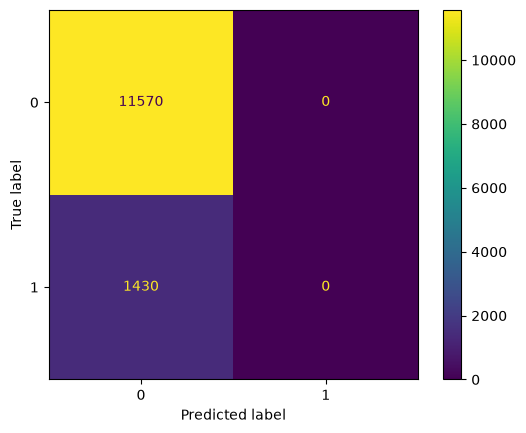

In [44]:
# Mostrar Matriz de Confusão
confusion_matriz_modelo = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matriz_modelo)
disp.plot()

- O gráfico mostra que a arvore está com um problema de esbalanceamento de classesm ela aprendeu a classificar tudo como 0.
- O modelo previu 0 Instancias de valor 1

### Tuning de Hiperparemetros

- Vamos seguir com um ajuste de parametros para tentar melhorar o comportamento do treinamento, usando os hiperparametros, vamos utilizar uma biblioteca para buscar os melhores hiperparametros

In [46]:
# Ajustar hiperparametros do Modelo usando Optuna
# min_samples_leaf = Minimo de instancias reqeuerido para formar uma folha (nó terminal)
# mas_depth = Profundidade máxima da árvore

def decisiontree_optuna(trial):

  min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
  max_depth = trial.suggest_int('max_depth', 2, 8)

  dt_model.set_params(classifier__min_samples_leaf=min_samples_leaf)
  dt_model.set_params(classifier__max_depth=max_depth)

  scores = cross_val_score(dt_model, X, y, cv=cv_folds, scoring='accuracy')

  return scores.mean(

  )

In [47]:
# Executar a automação de experimentos
estudo_decisiontree = optuna.create_study(direction='maximize')
estudo_decisiontree.optimize(decisiontree_optuna, n_trials=100)

[I 2026-09-07 19:07:24,913] A new study created in memory with name: no-name-c8215a38-59a5-4e78-946f-7f560f38c376
[I 2026-09-07 19:07:24,977] Trial 0 finished with value: 0.8900000046150297 and parameters: {'min_samples_leaf': 18, 'max_depth': 8}. Best is trial 0 with value: 0.8900000046150297.
[I 2026-09-07 19:07:25,024] Trial 1 finished with value: 0.8900000046150297 and parameters: {'min_samples_leaf': 5, 'max_depth': 2}. Best is trial 0 with value: 0.8900000046150297.
[I 2026-09-07 19:07:25,068] Trial 2 finished with value: 0.8900000046150297 and parameters: {'min_samples_leaf': 17, 'max_depth': 3}. Best is trial 0 with value: 0.8900000046150297.
[I 2026-09-07 19:07:25,114] Trial 3 finished with value: 0.8900000046150297 and parameters: {'min_samples_leaf': 19, 'max_depth': 7}. Best is trial 0 with value: 0.8900000046150297.
[I 2026-09-07 19:07:25,167] Trial 4 finished with value: 0.8900000046150297 and parameters: {'min_samples_leaf': 2, 'max_depth': 5}. Best is trial 0 with value

In [48]:
# Mostrar melhor resultado e melhor conjunto de hiperparametros
print(f'Melhor acurácia: {estudo_decisiontree.best_value}')
print(f'Melhores parametros: {estudo_decisiontree.best_params}')

Melhor acurácia: 0.8900000046150297
Melhores parametros: {'min_samples_leaf': 18, 'max_depth': 8}


Avaliando o resultado desse modelo, notamos que falta features para que ele possa interpretar de uma forma melhor e conseguir identificar fraudes.

Uma sugestão de feature, seria calcular a diferença entre a o valor anterior e o valor pos e ver se tem diferença, caso sim, na nova variavel, tem um booleado, com isso, podemos ter parametros melhor de correlação entre as váriaveis 0 e 1.